# Pipeline A — Step 2: First-Differences Huber Regression

$$\Delta Y_{it} = \beta \cdot \Delta X_{it} + \Delta \epsilon_{it}$$

**Estimator:** Huber Regressor (robust terhadap outlier) — dipilih berdasarkan eksperimen `EXP_model_comparison.ipynb`.

| Model | Level Test RMSE | Level Test R² | Provinces > Naive |
|-------|:-:|:-:|:-:|
| OLS (sebelumnya) | 0.00675 | 0.406 | 13/31 |
| **Huber (sekarang)** | **0.00554** | **0.600** | **14/31** |
| Naive baseline | 0.00477 | 0.704 | — |

**Improvement vs OLS:** RMSE turun 17.9%, R² naik dari 0.406 → 0.600.

In [200]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / 'pipeline_A' / 'output' / 'A1_annual_panel.csv').exists(): ROOT = p; break

out = ROOT / 'pipeline_A' / 'output'
df = pd.read_csv(out / 'A1_annual_panel.csv')
df = df.sort_values(['provinsi_id','tahun']).reset_index(drop=True)
df['x5_internet'] = df.groupby('provinsi_id')['x5_internet'].transform(lambda s: s.bfill())
print(f'Loaded: {len(df)} rows, {df["provinsi_id"].nunique()} provinces, years {sorted(df["tahun"].unique())}')

Loaded: 124 rows, 31 provinces, years [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [201]:
# === Build First-Differences ===
econ_cols = ['x1_bi_rate_avg','x2_inflasi_avg','log_pdrb',
             'x4_tpt','x5_internet','x8_ldr','x9_npl','x10_umkm']

frames = []
for pid, g in df.groupby('provinsi_id'):
    g = g.sort_values('tahun')
    d = pd.DataFrame({
        'provinsi_id': g['provinsi_id'].iloc[1:].values,
        'nama_provinsi': g['nama_provinsi'].iloc[1:].values,
        'tahun': g['tahun'].iloc[1:].values,
        'y_level': g['twp90_avg'].iloc[1:].values,
        'y_prev': g['twp90_avg'].iloc[:-1].values,
    })
    d['dy'] = d['y_level'] - d['y_prev']
    for c in econ_cols:
        d[f'd_{c}'] = g[c].iloc[1:].values - g[c].iloc[:-1].values
    frames.append(d)

df_fd = pd.concat(frames, ignore_index=True).dropna().reset_index(drop=True)
dx_cols = [f'd_{c}' for c in econ_cols]

print(f'First-differences panel: {len(df_fd)} obs, years {sorted(df_fd["tahun"].unique())}')
display(df_fd.head())

First-differences panel: 93 obs, years [np.int64(2023), np.int64(2024), np.int64(2025)]


,provinsi_id,nama_provinsi,tahun,y_level,y_prev,dy,d_x1_bi_rate_avg,d_x2_inflasi_avg,d_log_pdrb,d_x4_tpt,d_x5_internet,d_x8_ldr,d_x9_npl,d_x10_umkm
0,1,Banten,2023,0.029208,0.025142,0.004067,1.812500,-0.002380,0.074242,-0.565,0.0810,0.0231,-0.0029,0.0016
1,1,Banten,2024,0.022292,0.029208,-0.006917,0.291667,0.022663,0.060551,-0.895,-0.0455,0.0009,0.0059,-0.0169
2,1,Banten,2025,0.024117,0.022292,0.001825,-0.812500,-0.007733,0.060688,-0.185,-0.0056,0.0055,0.0049,-0.0070
3,2,Dki Jakarta,2023,0.029475,0.025492,0.003983,1.812500,-0.001567,0.073873,-0.540,0.0356,0.0989,-0.0032,-0.0037
4,2,Dki Jakarta,2024,0.031242,0.029475,0.001767,0.291667,0.017142,0.065183,-0.930,0.0055,0.0847,-0.0013,-0.0032


In [202]:
# === Train/Test Split + Scaling ===
train_mask = df_fd['tahun'] <= 2024
test_mask  = df_fd['tahun'] == 2025

X_train_raw = df_fd.loc[train_mask, dx_cols].astype(float).values
y_train     = df_fd.loc[train_mask, 'dy'].astype(float).values
X_test_raw  = df_fd.loc[test_mask, dx_cols].astype(float).values
y_test      = df_fd.loc[test_mask, 'dy'].astype(float).values

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f'Train: {len(X_train)} obs | Test: {len(X_test)} obs')
print(f'Ratio obs:params = {len(X_train)/len(dx_cols):.1f}:1')

Train: 62 obs | Test: 31 obs
Ratio obs:params = 7.8:1


In [203]:
# === Fit Huber Regressor ===
model = HuberRegressor(epsilon=1.35, max_iter=500)
model.fit(X_train, y_train)

print(f'Huber epsilon: {model.epsilon}')
print(f'Intercept: {model.intercept_:.6f}')
print(f'Training outlier fraction: {model.outliers_.mean()*100:.1f}% of training obs classified as outliers')

Huber epsilon: 1.35
Intercept: -0.001758
Training outlier fraction: 38.7% of training obs classified as outliers


In [204]:
# === Evaluate ===
dy_train_pred = model.predict(X_train)
dy_test_pred  = model.predict(X_test)

test_df = df_fd.loc[test_mask].copy().reset_index(drop=True)
test_df['dy_pred'] = dy_test_pred
test_df['y_pred_level'] = (test_df['y_prev'] + test_df['dy_pred']).clip(lower=0)
test_df['y_naive'] = test_df['y_prev']

train_df = df_fd.loc[train_mask].copy().reset_index(drop=True)
train_df['dy_pred'] = dy_train_pred
train_df['y_pred_level'] = (train_df['y_prev'] + train_df['dy_pred']).clip(lower=0)

def metrics(yt, yp, name):
    return {'model': name, 'n': len(yt),
            'rmse': np.sqrt(mean_squared_error(yt, yp)),
            'mae':  mean_absolute_error(yt, yp),
            'r2':   r2_score(yt, yp)}

ml_train = metrics(train_df['y_level'].values, train_df['y_pred_level'].values, 'Huber FD Level (Train)')
ml_test  = metrics(test_df['y_level'].values, test_df['y_pred_level'].values, 'Huber FD Level (Test)')
mn_test  = metrics(test_df['y_level'].values, test_df['y_naive'].values, 'Naive y=y_{t-1}')

print('='*70)
print(f'{"Model":<28} {"N":>4} {"RMSE":>10} {"MAE":>10} {"R2":>8}')
print('-'*70)
for m in [ml_train, ml_test, mn_test]:
    print(f'{m["model"]:<28} {m["n"]:>4} {m["rmse"]:>10.6f} {m["mae"]:>10.6f} {m["r2"]:>8.4f}')
print('='*70)

gap = abs(ml_train['rmse'] - ml_test['rmse']) / ml_test['rmse'] * 100
neg = (test_df['y_pred_level'] < 0).sum()
n_beat_naive = (test_df['y_pred_level'] - test_df['y_level']).abs() < (test_df['y_naive'] - test_df['y_level']).abs()

print(f'\nOverfitting gap: {gap:.1f}%')
print(f'Negative predictions: {neg}/31')
print(f'Provinces beating naive: {n_beat_naive.sum()}/31')
print(f'Improvement vs OLS: RMSE {((0.00675 - ml_test["rmse"])/0.00675*100):.1f}%, R2 {ml_test["r2"]:.3f} vs 0.406')

pd.DataFrame([ml_train, ml_test, mn_test]).to_csv(out / 'A2_metrics.csv', index=False)

Model                           N       RMSE        MAE       R2
----------------------------------------------------------------------
Huber FD Level (Train)         62   0.005878   0.003589   0.6411
Huber FD Level (Test)          31   0.005542   0.004313   0.5999
Naive y=y_{t-1}                31   0.004768   0.003195   0.7038

Overfitting gap: 6.1%
Negative predictions: 0/31
Provinces beating naive: 14/31
Improvement vs OLS: RMSE 17.9%, R2 0.600 vs 0.406


In [205]:
# === Coefficients (inverse-transform back to original scale for interpretability) ===
coef_scaled = model.coef_
# Unscale: beta_orig = beta_scaled / std(X)
coef_orig = coef_scaled / scaler.scale_

coeff_df = pd.DataFrame({
    'feature': dx_cols,
    'coef_scaled': coef_scaled.round(6),
    'coef_original_scale': coef_orig.round(6),
    'abs_importance': np.abs(coef_scaled),
}).sort_values('abs_importance', ascending=False).reset_index(drop=True)

print('=== Huber Coefficients (sorted by importance) ===')
print('Note: coef_scaled = importance ranking | coef_original = interpretable magnitude')
display(coeff_df.drop('abs_importance', axis=1))
coeff_df.drop('abs_importance', axis=1).to_csv(out / 'A2_coefficients.csv', index=False)

=== Huber Coefficients (sorted by importance) ===
Note: coef_scaled = importance ranking | coef_original = interpretable magnitude


,feature,coef_scaled,coef_original_scale
0,d_x2_inflasi_avg,-0.002475,-0.201322
1,d_x1_bi_rate_avg,-0.002233,-0.002937
2,d_x9_npl,-0.001445,-0.206536
3,d_x5_internet,0.000962,0.016981
4,d_x8_ldr,0.000801,0.013474
5,d_log_pdrb,0.000359,0.011475
6,d_x4_tpt,-0.000260,-0.000817
7,d_x10_umkm,-0.000067,-0.002980


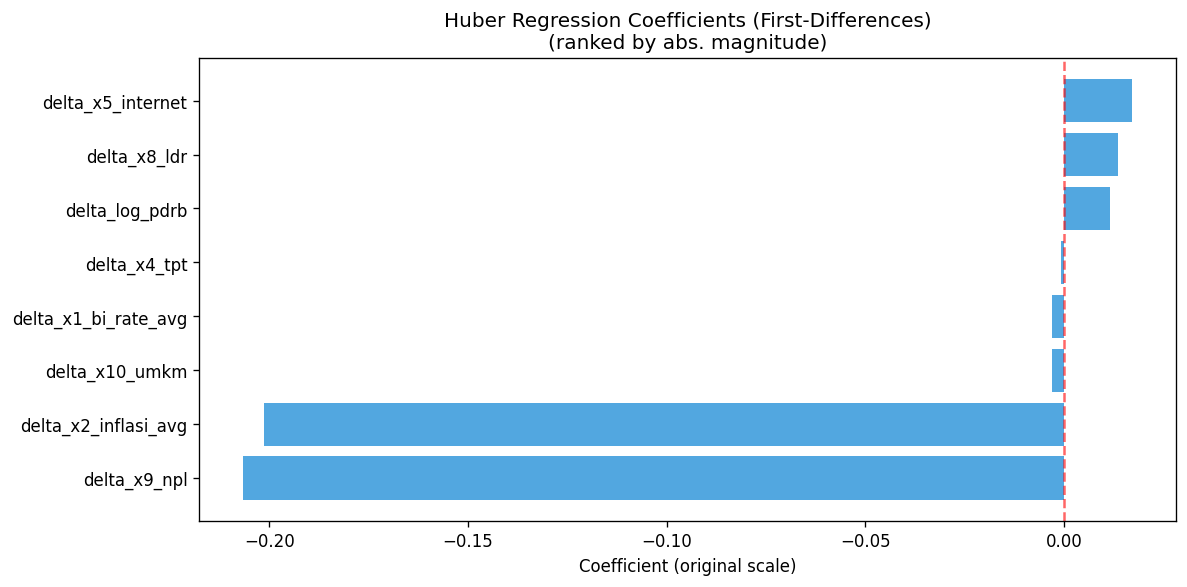

In [206]:
# === VIZ 1: Coefficient Plot (original scale) ===
fig, ax = plt.subplots(figsize=(10, 5))
sorted_coeff = coeff_df.sort_values('coef_original_scale')
colors = ['#3498db' if v != 0 else 'lightgray' for v in sorted_coeff['coef_original_scale']]
ax.barh(range(len(sorted_coeff)), sorted_coeff['coef_original_scale'], color=colors, alpha=0.85)
ax.axvline(0, color='red', ls='--', alpha=0.6)
ax.set_yticks(range(len(sorted_coeff)))
ax.set_yticklabels([f.replace('d_','delta_') for f in sorted_coeff['feature']])
ax.set_xlabel('Coefficient (original scale)')
ax.set_title('Huber Regression Coefficients (First-Differences)\n(ranked by abs. magnitude)')
fig.tight_layout()
fig.savefig(out / 'A2_coefficient_plot.png', dpi=150, bbox_inches='tight')
plt.show()

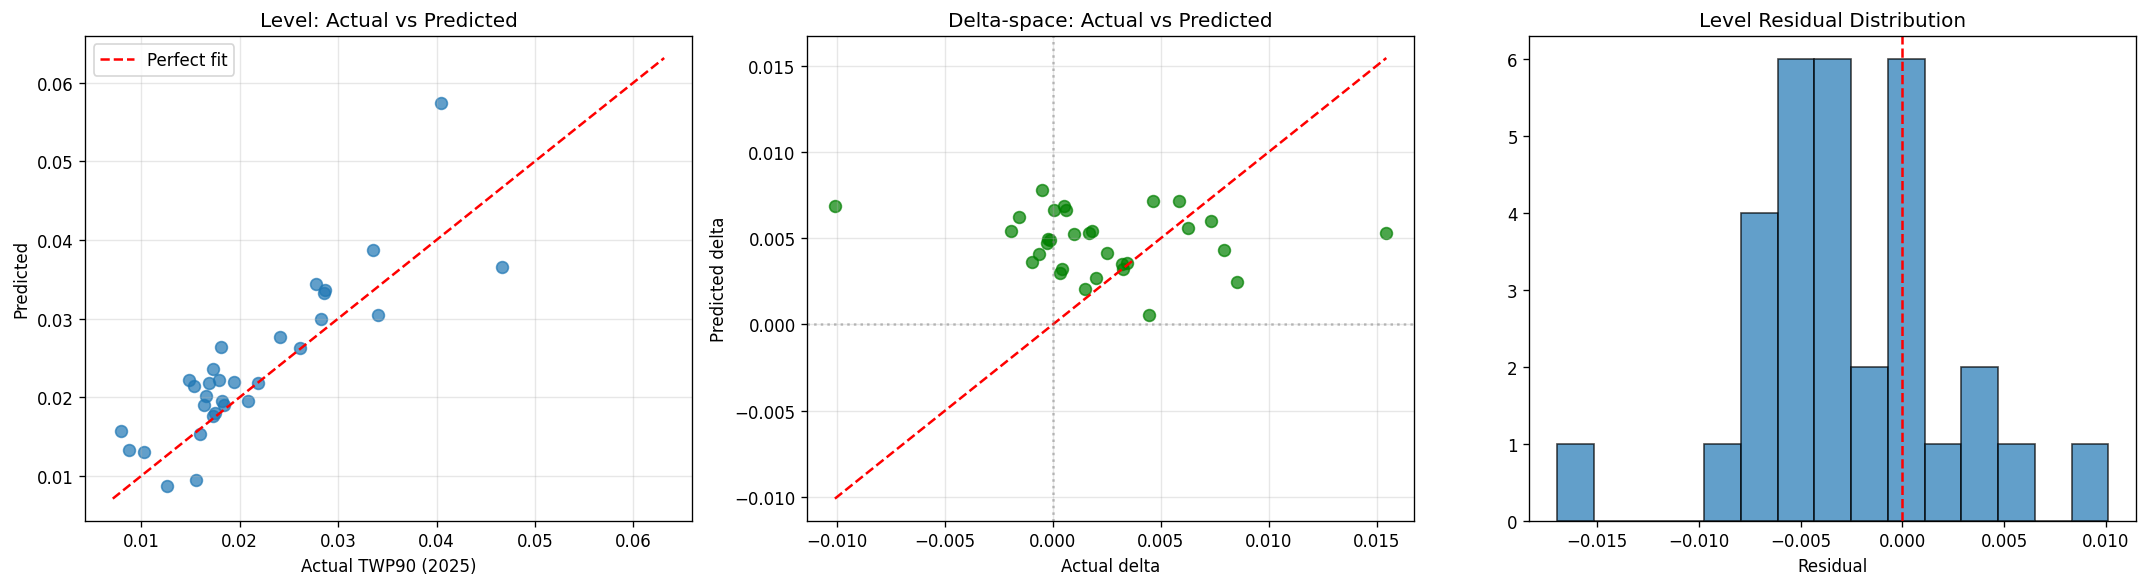

In [207]:
# === VIZ 2: Diagnostics ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.scatter(test_df['y_level'], test_df['y_pred_level'], alpha=0.7, s=50)
lims = [min(test_df['y_level'].min(), test_df['y_pred_level'].min())*0.9,
        max(test_df['y_level'].max(), test_df['y_pred_level'].max())*1.1]
ax.plot(lims, lims, 'r--', label='Perfect fit')
ax.set_xlabel('Actual TWP90 (2025)'); ax.set_ylabel('Predicted')
ax.set_title('Level: Actual vs Predicted'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(y_test, dy_test_pred, alpha=0.7, s=50, color='green')
dlims = [min(y_test.min(), dy_test_pred.min()), max(y_test.max(), dy_test_pred.max())]
ax.plot(dlims, dlims, 'r--')
ax.axhline(0, color='gray', ls=':', alpha=0.5); ax.axvline(0, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Actual delta'); ax.set_ylabel('Predicted delta')
ax.set_title('Delta-space: Actual vs Predicted'); ax.grid(True, alpha=0.3)

ax = axes[2]
resid = test_df['y_level'] - test_df['y_pred_level']
ax.hist(resid, bins=15, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', ls='--')
ax.set_title('Level Residual Distribution'); ax.set_xlabel('Residual')

fig.tight_layout()
fig.savefig(out / 'A2_prediction_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

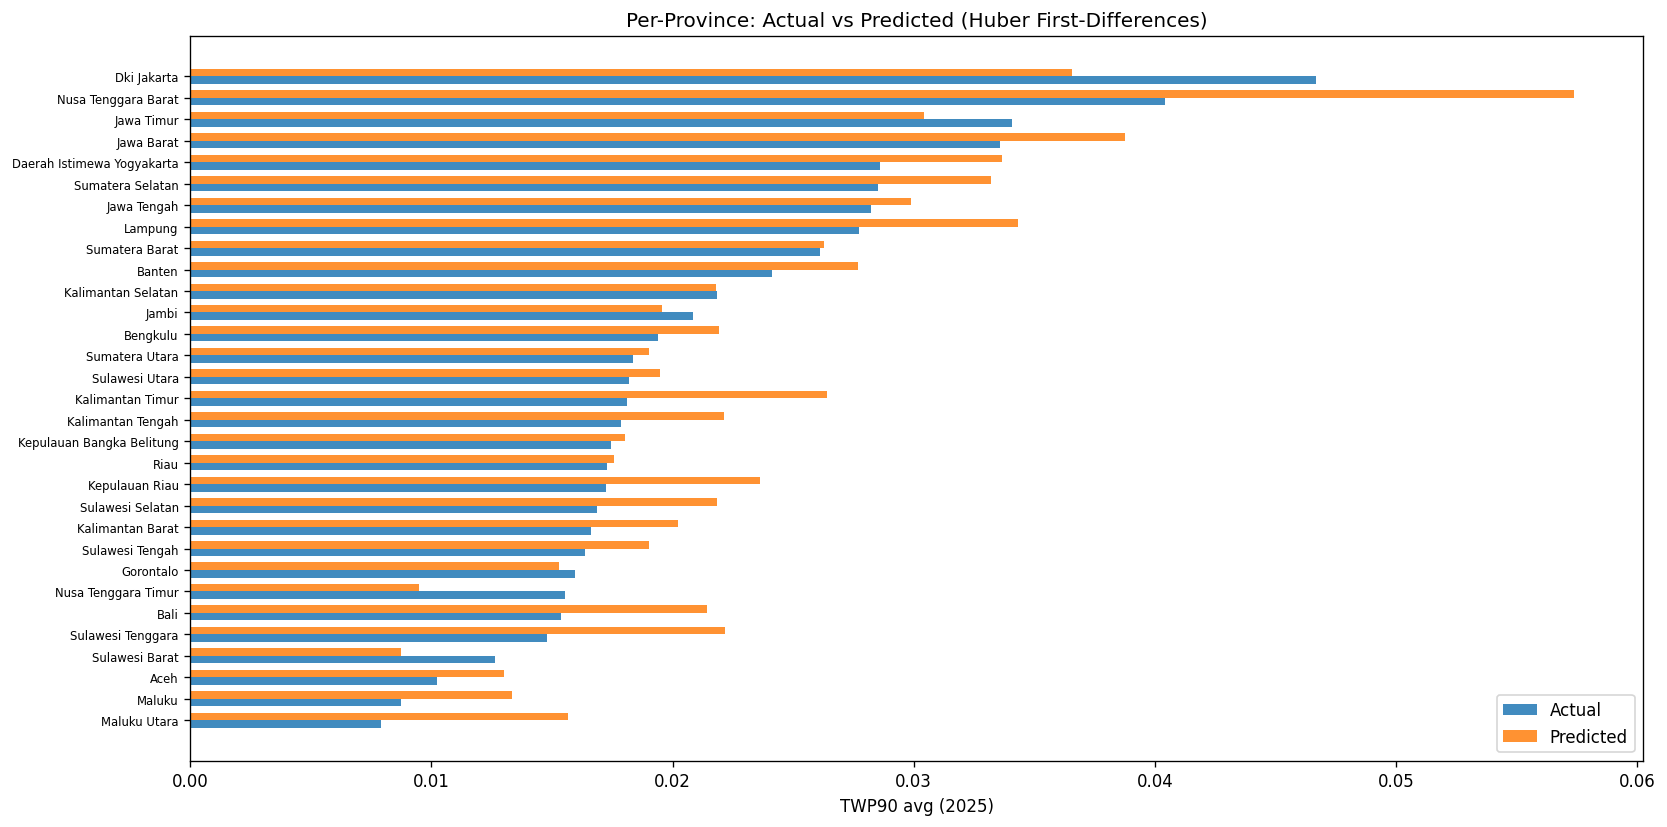

All outputs saved to: c:\Users\bimyu\Documents\Projects\DatathonMETC\pipeline_A\output


In [208]:
# === VIZ 3: Per-Province ===
prov = test_df.sort_values('y_level')

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(prov)); w = 0.35
ax.barh(x - w/2, prov['y_level'],       w, label='Actual',    alpha=0.85)
ax.barh(x + w/2, prov['y_pred_level'],  w, label='Predicted', alpha=0.85)
ax.set_yticks(x); ax.set_yticklabels(prov['nama_provinsi'], fontsize=7)
ax.set_xlabel('TWP90 avg (2025)')
ax.set_title('Per-Province: Actual vs Predicted (Huber First-Differences)')
ax.legend(); fig.tight_layout()
fig.savefig(out / 'A2_per_province_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

test_df[['provinsi_id','nama_provinsi','tahun','y_level','y_pred_level','y_naive','dy','dy_pred']].rename(
    columns={'y_level':'twp90_actual','y_pred_level':'twp90_predicted','y_naive':'twp90_naive'}
).to_csv(out / 'A2_predictions.csv', index=False)

print(f'All outputs saved to: {out}')

In [209]:
# === Save model summary (human-readable) ===
summary_lines = [
    'Pipeline A — First-Differences Huber Regression',
    '='*60,
    f'Estimator    : HuberRegressor(epsilon=1.35)',
    f'Train data   : delta-2023, delta-2024 ({len(X_train)} obs)',
    f'Test data    : delta-2025 ({len(X_test)} obs)',
    f'Parameters   : {len(dx_cols)+1} (intercept + 8 features)',
    f'Obs:Param    : {len(X_train)/(len(dx_cols)+1):.1f}:1',
    '',
    'PERFORMANCE (Level-space)',
    '-'*40,
    f'Train RMSE   : {ml_train["rmse"]:.6f}',
    f'Test  RMSE   : {ml_test["rmse"]:.6f}',
    f'Naive RMSE   : {mn_test["rmse"]:.6f}',
    f'Train R2     : {ml_train["r2"]:.4f}',
    f'Test  R2     : {ml_test["r2"]:.4f}',
    f'Naive R2     : {mn_test["r2"]:.4f}',
    f'Overfitting  : {gap:.1f}%',
    f'Neg preds    : {neg}/31',
    f'Beats naive  : {n_beat_naive.sum()}/31 provinces',
    '',
    'vs OLS (previous):',
    f'  RMSE improvement: {((0.00675-ml_test["rmse"])/0.00675*100):.1f}%',
    f'  R2 improvement  : {ml_test["r2"]-0.406:.3f} ({0.406:.3f} -> {ml_test["r2"]:.3f})',
    '',
    'COEFFICIENTS (original scale, sorted by |coef|)',
    '-'*40,
]
for _, row in coeff_df.iterrows():
    feat = row['feature'].replace('d_','delta_')
    summary_lines.append(f'  {feat:<28}: {row["coef_original_scale"]:>10.6f}')
summary_lines += [
    '',
    'NOTES',
    '-'*40,
    '[1] Huber is robust to outliers (epsilon=1.35, M-estimator).',
    '[2] Coefficients = association, NOT causation.',
    '[3] Model provides directional insight & province ranking.',
    '[4] For point-forecast precision, model still below naive.',
    '[5] Features standardized (StandardScaler) before fitting.',
]

summary_text = '\n'.join(summary_lines)
print(summary_text)
with open(out / 'A2_ols_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary_text)

Pipeline A — First-Differences Huber Regression
Estimator    : HuberRegressor(epsilon=1.35)
Train data   : delta-2023, delta-2024 (62 obs)
Test data    : delta-2025 (31 obs)
Parameters   : 9 (intercept + 8 features)
Obs:Param    : 6.9:1

PERFORMANCE (Level-space)
----------------------------------------
Train RMSE   : 0.005878
Test  RMSE   : 0.005542
Naive RMSE   : 0.004768
Train R2     : 0.6411
Test  R2     : 0.5999
Naive R2     : 0.7038
Overfitting  : 6.1%
Neg preds    : 0/31
Beats naive  : 14/31 provinces

vs OLS (previous):
  RMSE improvement: 17.9%
  R2 improvement  : 0.194 (0.406 -> 0.600)

COEFFICIENTS (original scale, sorted by |coef|)
----------------------------------------
  delta_x2_inflasi_avg        :  -0.201322
  delta_x1_bi_rate_avg        :  -0.002937
  delta_x9_npl                :  -0.206536
  delta_x5_internet           :   0.016981
  delta_x8_ldr                :   0.013474
  delta_log_pdrb              :   0.011475
  delta_x4_tpt                :  -0.000817
  delt